## Data Load

Data Leakage
- Data Leakage란 Test 데이터의 일부 또는 전체를 사용하여 모델 학습에 직,간접적으로 학습시키는 행위
- 왜 하면안되는가? --> Test 데이터의 정보를 활용하게 되면 성능이 일반적으로 향상되기 때문에 거의 모든 대회에서 부정행위로 간주됨.


아래 링크의 글을 확인해보시면 좋을 것 같습니다.

https://dacon.io/forum/405758


In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
for col_name in df.columns:
    print(f'{col_name}: {len(df[col_name].value_counts())}')

PassengerId: 891
Survived: 2
Pclass: 3
Name: 891
Sex: 2
Age: 88
SibSp: 7
Parch: 7
Ticket: 681
Fare: 248
Cabin: 147
Embarked: 3


1. PassengerId = 인덱스 (필요없는 정보)
2. Survived = Label (예측해야하는 정보)
3. Pclass = TicketClass
4. Name = 이름 (의미가 거의 없음)
5. Sex = 성별
6. Age = 나이
7. SibSp = 타이타닉호에 같이 탑승한 형제 / 자매의 수
8. Parch = 타이타닉호에 같이 탑승한 부모 / 아이의 수
9. Ticket = 티켓의 번호 (의미가 거의 없음)
10. Fare = 티켓 요금
11. Cabin = 객실 번호
12. Embarked = 출방항 위치 (C = Cherbourg, Q = Queenstown, S = Southampton)

## EDA

<Axes: xlabel='Pclass', ylabel='count'>

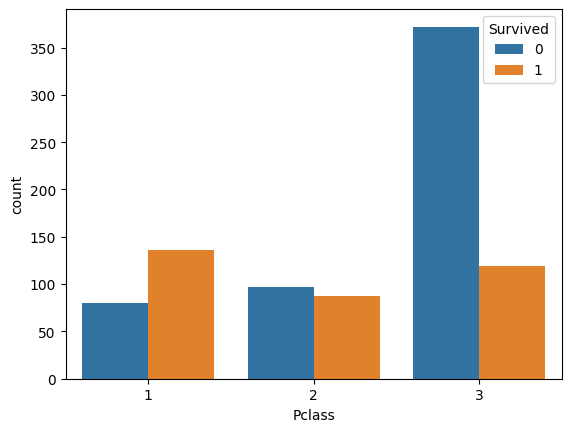

In [4]:
import seaborn as sns

sns.countplot(x=df['Pclass'], hue=df['Survived'])

Class가 높을수록 생존 확률이 높다.

<Axes: xlabel='Sex', ylabel='count'>

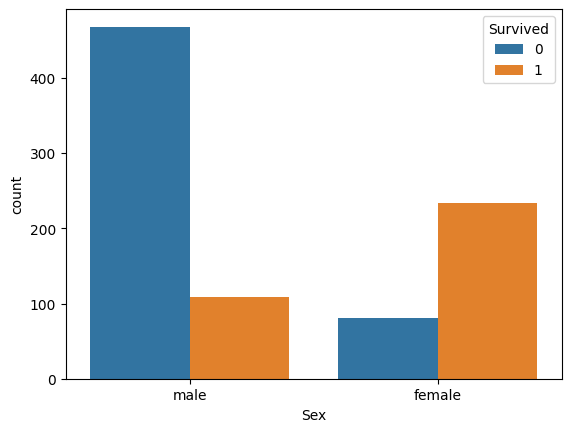

In [5]:
sns.countplot(x=df['Sex'], hue=df['Survived'])

여성이 남성보다 생존 확률이 높다.

<Axes: xlabel='Age'>

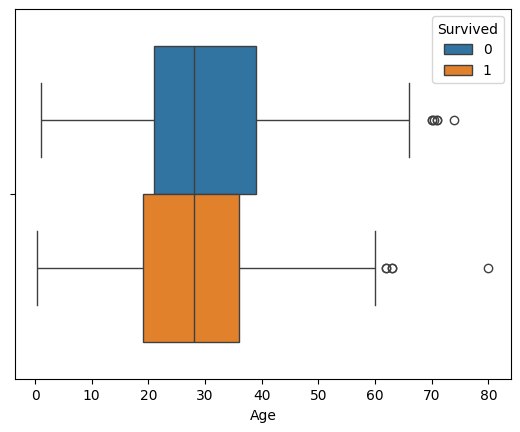

In [6]:
sns.boxplot(x=df['Age'], hue=df['Survived'])

<Axes: xlabel='Age', ylabel='Count'>

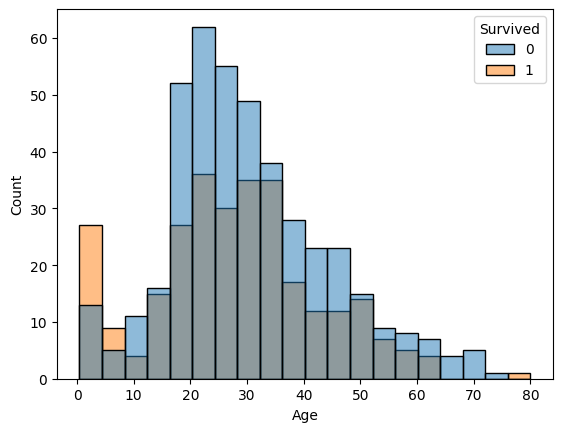

In [7]:
sns.histplot(x=df['Age'], hue=df['Survived'])

나이가 생존확률에 큰 영향을 주지는 않는 것 같다.

<Axes: xlabel='SibSp', ylabel='Probability'>

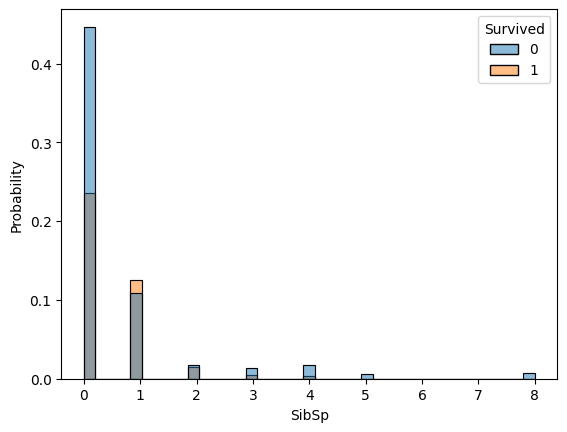

In [8]:
sns.histplot(x=df['SibSp'], hue=df['Survived'], stat='probability')

형제 / 자매의 수가 큰 영향을 주지는 않아보임.

<Axes: xlabel='Parch', ylabel='Probability'>

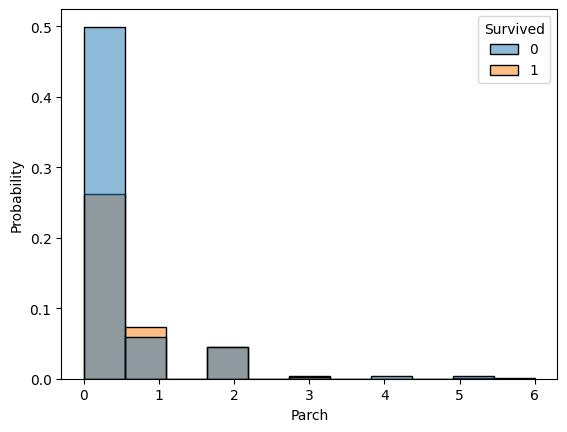

In [9]:
sns.histplot(x=df['Parch'], hue=df['Survived'], stat='probability')

자녀 / 부모의 수도 마찬가지

<Axes: xlabel='Fare'>

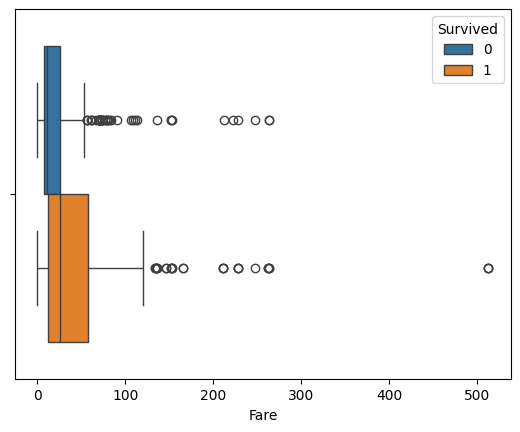

In [10]:
sns.boxplot(x=df['Fare'], hue=df['Survived'])

티켓값이 비쌀수록 생존 확률이 높다.

<Axes: xlabel='Embarked', ylabel='count'>

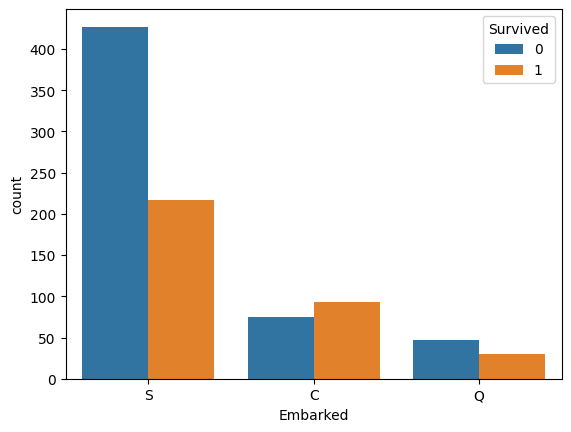

In [11]:
sns.countplot(x=df['Embarked'], hue=df['Survived'])

<Axes: xlabel='Survived', ylabel='count'>

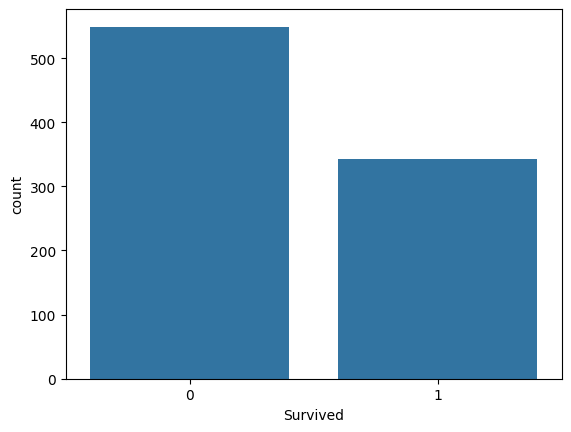

In [12]:
sns.countplot(x=df['Survived'])

출발 항구가 S면 사망확률이 높음.
출발 항구가 C면 사망확률이 적음.

In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


저는 변수를 최대한 제거하지 않는 편이지만,    
Index거나, 특정 열이 모든 행에 대해서 중복된 값을 가지고 있는 경우는 지웁니다.


In [14]:
#필요없는 변수 제거
drop_list = ['PassengerId', 'Cabin', 'Name', 'Ticket']
df = df.drop(drop_list, axis=1)
test_df = test_df.drop(drop_list, axis=1) #test_df.drop(columns=drop_list)

In [15]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 데이터 전처리
1. Sex Feature Encoding (Encoding이란 컴퓨터가 쉽게 이해할 수 있도록 자연어, 문자 등을 숫자로 바꿔주는 작업을 의미)
2. Age 피처에 대해서 Null값 채우기
3. Embarked Feature Encoding + Null값 있는 행 버리기 (2개 존재)

In [16]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [17]:
df = df[~df['Embarked'].isna()].reset_index(drop=True)
test_df['Embarked'] = test_df['Embarked'].fillna('S') #Test data는 Drop을 못하니 최빈값으로 채워주겠습니다.

In [18]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

OHE = OneHotEncoder()
OE = OrdinalEncoder()

df['Sex'] = OE.fit_transform(df['Sex'].to_numpy().reshape(-1, 1))
test_df['Sex'] = OE.transform(test_df['Sex'].to_numpy().reshape(-1, 1))



train_emb = OHE.fit_transform(df[['Embarked']]).toarray()
train_emb = pd.DataFrame(train_emb, columns=OHE.get_feature_names_out(['Embarked']))

df = pd.concat([df.drop(columns=['Embarked']), train_emb], axis=1)


test_emb = OHE.transform(test_df[['Embarked']]).toarray()
test_emb = pd.DataFrame(test_emb, columns=OHE.get_feature_names_out(['Embarked']))

test_df = pd.concat([test_df.drop(columns=['Embarked']), test_emb], axis=1)


### Null값을 제거하는 방법
Null값을 처리하는 방법은 정말 여러가지가 있음.
1. Null값이 있는 행을 제거
2. Null값이 있는 열을 제거
3. 다른 변수들로 Null값을 예측하여 채우기
4. 그냥 인덱스를 기준으로 한다든지 특정 기준으로 위에있는 값을 그대로 가져오기 등
5. 평균을 넣어주기


저는 그냥 Null값이 있는 행을 지우거나 도메인 지식 기반으로 최대한 그 값을 채우려고 합니다.     
아래에서는 그냥 평균값으로 채우도록 할게요.

In [19]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1.0,22.0,1,0,7.2500,0.0,0.0,1.0
1,1,1,0.0,38.0,1,0,71.2833,1.0,0.0,0.0
2,1,3,0.0,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,1,0.0,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,3,1.0,35.0,0,0,8.0500,0.0,0.0,1.0


In [20]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
test_df['Age'] = test_df['Age'].fillna(df['Age'].mean())


아래 코드의 문제점은 뭘까요 ❓

In [21]:
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].mean())

In [22]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Sex         418 non-null    float64
 2   Age         418 non-null    float64
 3   SibSp       418 non-null    int64  
 4   Parch       418 non-null    int64  
 5   Fare        418 non-null    float64
 6   Embarked_C  418 non-null    float64
 7   Embarked_Q  418 non-null    float64
 8   Embarked_S  418 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 29.5 KB


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Sex         889 non-null    float64
 3   Age         889 non-null    float64
 4   SibSp       889 non-null    int64  
 5   Parch       889 non-null    int64  
 6   Fare        889 non-null    float64
 7   Embarked_C  889 non-null    float64
 8   Embarked_Q  889 non-null    float64
 9   Embarked_S  889 non-null    float64
dtypes: float64(6), int64(4)
memory usage: 69.6 KB


이 외에도 Feature Engineering 중 하나인 파생 변수 생성이 굉장히 중요합니다.
파생 변수란 현재 가지고 있는 변수들에 본인이 가지고 있는 지식을 더해서 새로운 변수를 파생하는 것을 의미합니다.

예를들어 날짜 변수가 있는 경우 [주말인 경우 / 주말이 아닌 경우]에 대한 파생변수를 만들 수 있습니다.

## 모델 학습 및 평가

1. 적절한 모델을 선택하고 파라미터를 튜닝하기
2. Validation Set 잘 구축하기

In [24]:
X = df.drop(['Survived'], axis=1)
y = df['Survived']

Validation을 구축하는 방법은 여러가지가 있습니다.
1. Hold-Out Method
2. KFold
3. Stratified KFold
4. Group KFold
5. Leave-One-Out

주로 3번을 많이 사용하긴 하나 대회 test 데이터에 맞게 validation dataset을 구축하는 것이 중요합니다.
이번에는 간단하게 Hold out Method를 사용하겠습니다.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 모델 생성
model = LogisticRegression(max_iter=1000)

# 학습
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7847533632286996
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       141
           1       0.68      0.77      0.72        82

    accuracy                           0.78       223
   macro avg       0.77      0.78      0.77       223
weighted avg       0.79      0.78      0.79       223



In [27]:
test_y_pred = model.predict(test_df)

In [28]:
submit_df = pd.read_csv('/kaggle/input/competitions/titanic/gender_submission.csv')
submit_df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [29]:
submit_df['Survived'] = test_y_pred

In [30]:
submit_df.to_csv('submission.csv', index=False)